In [2]:
%load_ext autoreload
%autoreload 2

#### Importing

In [6]:
import json
from functools import partial
import numpy as np
import pandas as pd
import torch
from fancy_einsum import einsum

from transformers import AutoModelForCausalLM
from datasets import load_from_disk


import transformer_lens as tl
from circuitsvis.attention import attention_heads
import transformer_lens.utils as utils
from transformer_lens import ActivationCache, HookedTransformer, HookedTransformerConfig

from geomechinterp.causal.mygpt import SymbolTokenizer, DataCollator
from geomechinterp.tflens.utils import load_gpt2_to_hooked_transformer
from geomechinterp.causal.base_functions import all_binary_generators_func_names
from geomechinterp.causal.utils import DisplayChain

In [13]:
from IPython.display import HTML, IFrame
from tqdm import tqdm

import plotly.express as px
import plotly.graph_objects as go
from matplotlib import pyplot as plt
import plotly.io as pio

#### Loading Model

In [5]:
model_hf = AutoModelForCausalLM.from_pretrained("../gpt_rope_custom/checkpoint-407000/")


hook_config = HookedTransformerConfig(d_vocab=29, n_ctx=128, d_model=128,
                                      d_head=32, n_layers=6, n_heads=4,
                                      rotary_dim=64, act_fn='gelu_new', 
                                      original_architecture='GPT2LMHeadModel')

model = load_gpt2_to_hooked_transformer(model_hf, hook_config)

# model.tokenizer = SymbolTokenizer()

model_hf.to("mps").eval()
model.to("mps").eval()
print('')

Moving model to device:  mps



In [4]:
input_ids = torch.tensor([1, 2, 3, 3, 1, 2, 5, 6, 2, 10, 2, 3, 15, 18, 20, 7]).to("mps")

out1 = model_hf(input_ids)
out2, hooked_act = model.run_with_cache(input_ids)

k = 1
print('WARNING: SMALL DIFFERENCES IN ACTIVATIONS ARE ACCUMULATING, PROBABLY DUE TO DISREPANCIES IN THE LAYER NORM!')
print('---'*10)
for k in range(out2.shape[1]):
    # use cosine similarity after softmax
    print(torch.cosine_similarity(torch.nn.functional.softmax(out1['logits'][k,:], dim=-1), torch.nn.functional.softmax(out2[:,k,:], dim=-1)))    


------------------------------
tensor([0.9994], device='mps:0', grad_fn=<SumBackward1>)
tensor([1.], device='mps:0', grad_fn=<SumBackward1>)
tensor([1.], device='mps:0', grad_fn=<SumBackward1>)
tensor([1.0000], device='mps:0', grad_fn=<SumBackward1>)
tensor([1.], device='mps:0', grad_fn=<SumBackward1>)
tensor([1.], device='mps:0', grad_fn=<SumBackward1>)
tensor([0.9523], device='mps:0', grad_fn=<SumBackward1>)
tensor([1.], device='mps:0', grad_fn=<SumBackward1>)
tensor([0.9994], device='mps:0', grad_fn=<SumBackward1>)
tensor([0.9347], device='mps:0', grad_fn=<SumBackward1>)
tensor([1.], device='mps:0', grad_fn=<SumBackward1>)
tensor([1.], device='mps:0', grad_fn=<SumBackward1>)
tensor([0.9226], device='mps:0', grad_fn=<SumBackward1>)
tensor([0.9750], device='mps:0', grad_fn=<SumBackward1>)
tensor([0.9235], device='mps:0', grad_fn=<SumBackward1>)
tensor([0.9390], device='mps:0', grad_fn=<SumBackward1>)


#### Loading Dataset

In [7]:
tokenizer = SymbolTokenizer()
dataset = load_from_disk("../tokenized_train")
test_dataset = load_from_disk("../tokenized_test")

train_collator = DataCollator(dataset, device="mps")  
test_collator = DataCollator(test_dataset, device="mps")  

In [10]:
# select subset of deterministic patterns
deterministic_train_dataset = []
for case in dataset:
    if case['stochastic']:
        continue
    else:
        deterministic_train_dataset.append(case)

deterministic_test_dataset = []
for case in test_dataset:
    if case['stochastic']:
        continue
    else:
        deterministic_test_dataset.append(case)

print(len(deterministic_train_dataset))
print(len(deterministic_test_dataset))

1011
46


In [11]:
idx = 2
test_case = deterministic_test_dataset[idx]
out = model(torch.tensor(test_case['input_ids']).to("mps"))
decoded_str = tokenizer.decode(out.argmax(dim=-1).tolist())[0]

print(DisplayChain.from_json(test_case['generator'], base_functions=all_binary_generators_func_names))
print(test_case['text'][6:])
print(decoded_str[5:])

Chain of functions:
DependentFeature(function=plus_minus_f, controls=[ab_prev, position_parity], truth_table=[1, 0, 1, 1])
DependentFeature(function=ab_f, controls=[+-, ab_prev, position_parity], truth_table=[1, 0, 1, 1, 1, 1, 1, 0])
DependentFeature(function=case_f, controls=[+-, ab, ab_prev], truth_table=[1, 0, 0, 0, 0, 0, 0, 1])
+b +b +a -a +b +b +a -a +b +b +a -a +b +b +a -a +b +b +a -a +b +b +a -a +b +b +a -a
+a +a -a +a +b -b -b +b +b -b -a +b +a +b +a +b +a +b +a +a +b +b -


In [12]:
idx = 34
test_case = deterministic_test_dataset[idx]
out = model(torch.tensor(test_case['input_ids']))
decoded_str = tokenizer.decode(out.argmax(dim=-1).tolist())[0]

print(DisplayChain.from_json(test_case['generator'], base_functions=all_binary_generators_func_names))
print(test_case['text'][6:])
print(decoded_str[5:])

Chain of functions:
DependentFeature(function=plus_minus_f, controls=[position_parity], truth_table=[0, 1])
DependentFeature(function=ab_f, controls=[+-, ab_prev, position_parity], truth_table=[1, 0, 0, 1, 0, 1, 0, 1])
DependentFeature(function=case_f, controls=[+-, ab_prev, position_parity], truth_table=[0, 1, 0, 0, 0, 1, 1, 0])
+a -b +A -a +a -b +A -a +a -b +A -a +a -b +A -a +a -b +A -a +a -b +A -a +a -b +A -a
+A +a +A +a +a +b +a +b +a -b +a -a +a -b +A -a +a -b +A -a +a -b -


#### Visualize MyGPT Activations in Reduced Dimensions

#### Accumulate Activations

##### Deterministic Patterns Only (0.1% of the dataset)

In [12]:
# blocks.1.attn.hook_z
# blocks.2.hook_mlp_out
# blocks.2.hook_resid_post
# list(hooked_act.keys())

In [18]:
# deterministic_train_dataset


Dataset({
    features: ['text', 'generator', 'stochastic', 'sequence_of_features', 'input_ids'],
    num_rows: 407353
})

In [92]:
from datasets import Dataset

deterministic_test_dataset = Dataset.from_list(deterministic_test_dataset)
deterministic_train_dataset = Dataset.from_list(deterministic_train_dataset)

# drop all rows with text length < 5
deterministic_train_dataset = deterministic_train_dataset.filter(lambda x: len(x['text']) > 5)
deterministic_test_dataset = deterministic_test_dataset.filter(lambda x: len(x['text']) > 5)

Filter:   0%|          | 0/1010 [00:00<?, ? examples/s]

Filter:   0%|          | 0/46 [00:00<?, ? examples/s]

In [104]:
from geomechinterp.tflens.activations import accumulate_activations, load_precomputed_activation

selected_hooks = ['blocks.{i}.attn.hook_z', 'blocks.{i}.hook_mlp_out', 'blocks.{i}.hook_resid_post']
accumulate_activations(deterministic_test_dataset, selected_hooks, from_word_idx=10, select_num_chars=5, save_suffix='test_deterministic')
accumulate_activations(deterministic_train_dataset, selected_hooks, from_word_idx=10, select_num_chars=5, save_suffix='train_deterministic')

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

100%|██████████| 1/1 [00:01<00:00,  1.62s/it]


Map:   0%|          | 0/1010 [00:00<?, ? examples/s]

100%|██████████| 1/1 [00:03<00:00,  3.89s/it]


['tensors/accumulated_activations_train_deterministic_0.pt']

In [370]:
from geomechinterp.ds.emb_pipe import ActivationStatsPipeline   

selected_hooks = [f"blocks.{i}.hook_resid_post" for i in range(1, 6)]

emb_pipe = ActivationStatsPipeline(
    dataset=deterministic_train_dataset,
    activations_dir="tensors",
    activations_file_substring="train_deterministic",
    selected_hooks=selected_hooks,
)

emb_pipe.load_activations()

INFO:root:Using Lazy Loading of Activations from tensors
INFO:root:Built feature dataframe with 63 features
100%|██████████| 2/2 [00:00<00:00, 35.09it/s]
INFO:root:Loaded 5 hooked activations.
100%|██████████| 2/2 [00:00<00:00, 60.69it/s]
INFO:root:Loaded 5 hooked activations.


activations (1010, 10)
activations (1010, 10)


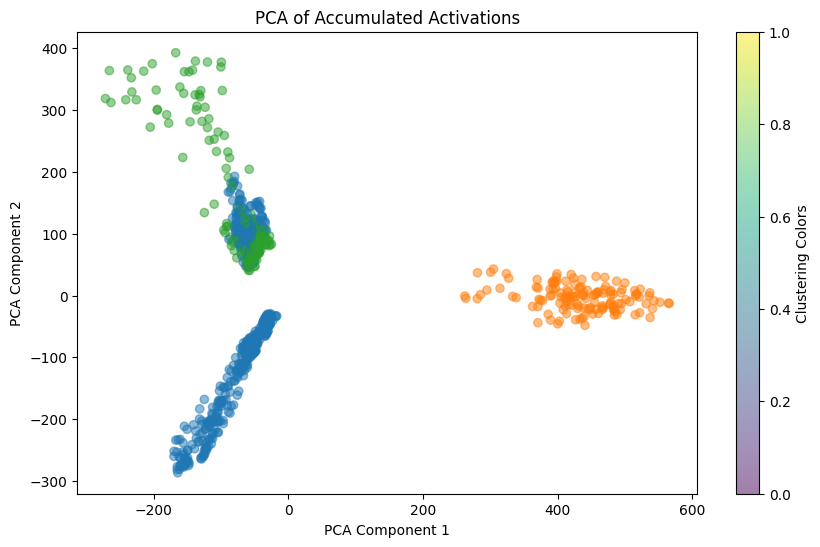

In [371]:
target_layer = 'blocks.5.hook_resid_post'
emb_pipe.cluster(activations_str=target_layer, agg_func=0, max_clusters=3, use_isomap=True)
emb_pipe.plot_pca()

In [368]:
emb_pipe.run_single(activations_str=target_layer, agg_func=0, filter_non_important=True)


activations (1010, 128)
activations (1010, 128)
activations (1010, 128)
activations (1010, 128)
activations (1010, 128)
activations (1010, 128)
activations (1010, 128)
activations (1010, 128)
activations (1010, 128)
activations (1010, 128)
activations (1010, 128)


{'blocks.5.hook_resid_post_0': {'clusters': array([6, 6, 3, ..., 5, 2, 2], dtype=int32),
  'anova':                     Feature   F-statistic        p-value  Adjusted p-value
  0             num_functions  12413.445846   0.000000e+00      0.000000e+00
  3               presence_+-    236.956657  1.371121e-255     8.638060e-254
  4               presence_><    236.956657  1.371121e-255     8.638060e-254
  5               presence_][    236.956657  1.371121e-255     8.638060e-254
  6               max_control    191.399596  3.467429e-224     2.184481e-222
  9           tt_size_8_count    138.486029  6.498442e-181     4.094019e-179
  10       tt_size_8_tt_sym_0    138.486029  6.498442e-181     4.094019e-179
  11       tt_size_8_tt_sym_1    138.486029  6.498442e-181     4.094019e-179
  12       tt_size_8_tt_sym_2    138.486029  6.498442e-181     4.094019e-179
  1                 num_edges    134.508921  2.761651e-177     1.739840e-175
  28  dag_equivalence_class_6     38.113663   1.225347e

In [373]:
results = emb_pipe.run_all()

In [374]:
results

{'blocks.5.hook_resid_post_0': {'clusters': array([6, 6, 3, ..., 5, 2, 2], dtype=int32),
  'anova':                     Feature   F-statistic        p-value  Adjusted p-value
  0             num_functions  12413.445846   0.000000e+00      0.000000e+00
  3               presence_+-    236.956657  1.371121e-255     8.638060e-254
  4               presence_><    236.956657  1.371121e-255     8.638060e-254
  5               presence_][    236.956657  1.371121e-255     8.638060e-254
  6               max_control    191.399596  3.467429e-224     2.184481e-222
  9           tt_size_8_count    138.486029  6.498442e-181     4.094019e-179
  10       tt_size_8_tt_sym_0    138.486029  6.498442e-181     4.094019e-179
  11       tt_size_8_tt_sym_1    138.486029  6.498442e-181     4.094019e-179
  12       tt_size_8_tt_sym_2    138.486029  6.498442e-181     4.094019e-179
  1                 num_edges    134.508921  2.761651e-177     1.739840e-175
  28  dag_equivalence_class_6     38.113663   1.225347e

#### Try predicting Analytical Features from Activations

In [232]:
from geomechinterp.ds.cluster import calculate_feature_importance, single_position, mean_across_positions, agg_across_positions

# Aggregate activations and calculate feature importance for clustering
positions = [0, 1, 2, 3, 4]  # Available positions
activations_np = accumulated_activations['blocks.5.hook_resid_post'].detach().cpu().numpy()
binarized_features = cat_data.to_numpy()
feature_names = cat_data.columns

# IMPORTANT - FEATURES HERE ARE CHANNELS IN THE LLM ACTIVATIONS, NOT THE "ANALYTICAL" FEATURES OF THE PATTERNS
# SO IT IS ESSENTIALLY A VARIATION ON THE LINEAR PROBE TEST

position_importances = {}
for pos in positions:
    X = single_position(activations_np, pos)
    y = binarized_features[:, 0]  # Example target: first binary feature
    importance_df, _ = calculate_feature_importance(X, y)
    # rename features from idx to column names
    importance_df.rename(columns={0: 'Feature'}, inplace=True)
    position_importances[pos] = importance_df

# b) Mean across positions
X_mean = mean_across_positions(activations_np)
y_mean = binarized_features[:, 0]  # Example target
mean_importance_df, _ = calculate_feature_importance(X_mean, y_mean)


# c) Aggregate across positions
X_agg = agg_across_positions(activations_np)
y_agg = binarized_features[:, 0]  # Example target
agg_importance_df, _ = calculate_feature_importance(X_agg, y_agg)

In [233]:
print("Feature Importance for Single Positions:")
for pos, importance in position_importances.items():
    print(f"Position {pos}:")
    print(importance.sort_values(by='RandomForestImportance', ascending=False).head(3))

print("\nFeature Importance for Mean Across Positions:")
print(mean_importance_df.sort_values(by='RandomForestImportance', ascending=False).head(5))

print("\nFeature Importance for Aggregate Across Positions:")
print(agg_importance_df.sort_values(by='RandomForestImportance', ascending=False).head(10))

Feature Importance for Single Positions:
Position 0:
    Feature  RandomForestImportance  PermutationImportance
58       58                0.089877                    0.0
83       83                0.089353                    0.0
11       11                0.089277                    0.0
Position 1:
    Feature  RandomForestImportance  PermutationImportance
85       85                0.050026               0.000792
7         7                0.049765               0.000000
90       90                0.049748               0.000000
Position 2:
    Feature  RandomForestImportance  PermutationImportance
11       11                0.069365                    0.0
83       83                0.069357                    0.0
35       35                0.069061                    0.0
Position 3:
    Feature  RandomForestImportance  PermutationImportance
39       39                0.130574                    0.0
10       10                0.092375                    0.0
73       73               

In [218]:
cat_data

,num_functions,num_edges,num_indep_funcs,presence_+-,presence_><,presence_][,max_control,tt_size_4_count,tt_size_4_OR,tt_size_8_count,...,labeled_graph_hash_24,labeled_graph_hash_25,labeled_graph_hash_20,labeled_graph_hash_19,labeled_graph_hash_2,labeled_graph_hash_6,labeled_graph_hash_23,labeled_graph_hash_22,labeled_graph_hash_8,labeled_graph_hash_0
0,3,8,0,1,0,0,3,1.0,2.0,2.0,...,0,0,0,0,1,0,0,0,0,0
1,3,5,1,1,0,0,3,1.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,1
2,3,6,0,1,0,0,3,1.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,1
3,3,8,0,1,0,0,3,1.0,0.0,2.0,...,0,0,0,0,0,0,0,0,0,0
4,3,8,0,1,0,0,3,1.0,0.0,2.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,3,8,0,1,0,0,3,1.0,0.0,2.0,...,0,0,0,0,0,0,0,0,0,0
1006,2,5,0,1,0,0,3,1.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1007,3,8,0,1,0,0,3,1.0,0.0,2.0,...,0,0,0,0,0,0,0,0,0,0
1008,3,7,0,1,0,0,3,2.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,1


In [219]:
cat_data.describe().T

,count,mean,std,min,25%,50%,75%,max
num_functions,1010.0,2.857426,0.349811,2.0,3.0,3.0,3.0,3.0
num_edges,1010.0,6.872277,1.519782,2.0,6.0,8.0,8.0,8.0
num_indep_funcs,1010.0,0.102970,0.310521,0.0,0.0,0.0,0.0,2.0
presence_+-,1010.0,0.896040,0.305360,0.0,1.0,1.0,1.0,1.0
presence_><,1010.0,0.103960,0.305360,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
labeled_graph_hash_6,1010.0,0.047525,0.212864,0.0,0.0,0.0,0.0,1.0
labeled_graph_hash_23,1010.0,0.007921,0.088690,0.0,0.0,0.0,0.0,1.0
labeled_graph_hash_22,1010.0,0.008911,0.094023,0.0,0.0,0.0,0.0,1.0
labeled_graph_hash_8,1010.0,0.041584,0.199736,0.0,0.0,0.0,0.0,1.0


In [220]:
accumulated_activations['blocks.5.hook_resid_post'].shape

torch.Size([1010, 5, 128])

In [153]:
from geomechinterp.utils import run_model_on_pattern, run_model_on_pattern_and_plot

In [ ]:
pattern = 'a a a a a a a a a a a a a a a a a a a a a a a a a'
loss = run_model_on_pattern(model, pattern)
print(loss)

In [ ]:
pattern = 'b b b b b b b b b b b b b b b b b b b b b b b b b'
_ = run_model_on_pattern_and_plot(model, pattern)

In [ ]:
pattern = 'a b a b a b a b a b a b a b a b a b a b a b a b a b'
_ = run_model_on_pattern_and_plot(model, pattern, annotate_tokens=True)

In [ ]:
pattern = '+ - + - + - + - + - + - + - + - + - + - + - + - + -'
_ = run_model_on_pattern_and_plot(model, pattern, annotate_tokens=True)

In [ ]:
ALL_DETERMINISTIC_PATTERNS_LIST = list(ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS2.keys())

losses = []
for pattern in ALL_DETERMINISTIC_PATTERNS_LIST:
    loss = run_model_on_pattern(model, pattern[2:], exclude_first_k=5)
    losses.append(loss)

df = pd.DataFrame({'pattern': [p[:29] for p in ALL_DETERMINISTIC_PATTERNS_LIST], 'loss': losses})

#### MyGPT Activation Patching and Circuit Analysis

In [ ]:
df.sort_values(by='loss', ascending=False)

In [ ]:
ALL_DETERMINISTIC_PATTERNS_LIST

In [ ]:
pattern = '+B -a -a +A +B -a -a +A +B -a -a +A +B -a -a +A +B -a -a +A'
print(ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS2[pattern]['generator'])
_ = run_model_on_pattern_and_plot(model, pattern, annotate_tokens=True)

In [ ]:
# check that all symbols in patters match to a single token
symbols = ['a','b', '+', '-', 'A', 'B', '1', '2', '>', '<', '?', '!', '[', ']', '(', ')']
for symbol in symbols:
    if symbol not in model.tokenizer.get_vocab():
        print(f"Symbol {symbol} not found in tokens")

In [ ]:

# Function to tokenize patterns, run them through the model, and measure uncertainty
def run_model_on_pattern_and_plot(model, pattern, device):
    # Preprocess pattern
    tokens = pattern.replace("...", "").split()  # Split the pattern into individual tokens
    token_ids = model.to_tokens(tokens).to(device)  # Convert tokens to token ids
    token_ids = token_ids[:, :512]  # Limit the sequence length if necessary

    # Forward pass through the model
    logits, cache = model(token_ids, return_type="logits")
    
    # Calculate uncertainty (entropy over logits)
    softmax_logits = torch.nn.functional.softmax(logits, dim=-1)
    entropy = -torch.sum(softmax_logits * torch.log(softmax_logits + 1e-8), dim=-1)

    # Return uncertainty (logit entropy) for each step
    return entropy.cpu().detach().numpy()

# Run model on each pattern and register uncertainty
uncertainties = {}
for pattern in patterns:
    uncertainties[pattern] = run_model_on_pattern_and_plot(model, pattern, device)

# Display the uncertainties for each pattern
for pattern, uncertainty in uncertainties.items():
    print(f"Pattern: {pattern}\nUncertainty at each step:\n{uncertainty}\n")